# Caso Pratico EMFI 1
**Autori:** Leonardo Pratelli, Sara Albotica – Università di Pisa  
**Docente:** Prof. Fulvio Corsi

---

## Parte A – Frontiera Efficiente

Questo notebook esegue in modo interattivo i punti della Parte A, mostrando grafici e risultati inline.  
Per modificare i titoli, le date o i parametri basta cambiare la cella di configurazione e rieseguire.

---
## Blocco 0 – Import e configurazione

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

# ── Configurazione asset ──────────────────────────────────────────────────────
# Struttura 3-3-3-1: tre settori da 3 titoli + 1 indice di mercato
# Modificare qui per cambiare i titoli senza toccare il resto del codice

TICKERS = {
    'Tech':       ['AAPL', 'MSFT', 'NVDA'],
    'Healthcare': ['JNJ',  'PFE',  'MRK'],
    'Energy':     ['XOM',  'CVX',  'BP'],
    'Index':      ['^GSPC'],
}
ALL_TICKERS = [t for group in TICKERS.values() for t in group]

START = '2015-01-01'
END   = '2025-01-01'   # 10 anni → ~120 osservazioni mensili

print('Titoli selezionati:', ALL_TICKERS)
print(f'Periodo: {START} → {END}')

Titoli selezionati: ['AAPL', 'MSFT', 'NVDA', 'JNJ', 'PFE', 'MRK', 'XOM', 'CVX', 'BP', '^GSPC']
Periodo: 2015-01-01 → 2025-01-01


---
## Blocco 1 – Download prezzi mensili da Yahoo Finance

**Punto 1 della traccia.**

- `auto_adjust=True` → prezzi già rettificati per dividendi e split (total return)
- `.resample('ME').last()` → aggregazione mensile: si prende l'ultimo giorno di borsa aperta del mese
- I dati coprono 10 anni (≈120 osservazioni mensili) come richiesto dalla traccia

In [4]:
raw = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True, progress=True)
prices = raw['Close'].resample('ME').last()

# Rinomina ^GSPC → SP500 per comodità nelle colonne
prices.columns = [c if c != '^GSPC' else 'SP500' for c in prices.columns]
prices.dropna(how='all', inplace=True)

print(f'\nOsservazioni mensili: {len(prices)}')
print(f'Periodo effettivo: {prices.index[0].date()} → {prices.index[-1].date()}')
prices.tail()

[*********************100%***********************]  10 of 10 completed


Osservazioni mensili: 120
Periodo effettivo: 2015-01-31 → 2024-12-31


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
Date,,,,,,,,,,
2024-08-31,227.505539,31.125780,138.611603,158.808426,111.671959,412.317108,119.312469,26.199945,112.090363,5648.399902
2024-09-30,231.479446,28.770267,137.974533,155.169983,107.778076,425.324921,121.391869,26.136724,111.406067,5762.479980
2024-10-31,224.435699,26.909687,139.426712,153.063538,97.110352,401.651886,132.707367,25.558722,110.987900,5705.450195
2024-11-30,236.040588,27.296419,153.256775,149.610626,96.464973,419.401855,138.195206,24.038841,113.030586,6032.379883
2024-12-31,249.059464,27.529245,137.082153,139.582520,95.170723,417.460632,134.246017,24.332335,103.074768,5881.629883


---
## Blocco 2 – Rendimenti logaritmici mensili

**Perché i rendimenti logaritmici?**
- `r_t = ln(P_t / P_{t-1})` — additivi nel tempo, simmetrici, più vicini alla normalità
- La prima riga (NaN) viene eliminata con `.dropna()`

In [5]:
returns = np.log(prices / prices.shift(1)).dropna()

print(f'Osservazioni di rendimento: {len(returns)}')
returns.head()

Osservazioni di rendimento: 119


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
Date,,,,,,,,,,
2015-02-28,0.096016,0.079706,0.049454,0.030367,-0.029290,0.089036,0.142699,0.102492,0.020229,0.053439
2015-03-31,-0.031874,-0.057868,-0.016064,-0.018808,-0.010214,-0.075530,-0.052583,0.013602,-0.040803,-0.017549
2015-04-30,0.005770,0.098536,0.056301,-0.014014,0.035547,0.179202,0.058909,-0.025030,0.027500,0.008485
2015-05-31,0.044341,-0.026166,-0.065426,0.016697,0.022085,-0.030804,0.001460,0.032120,-0.016913,0.010437
2015-06-30,-0.037938,-0.036850,-0.065497,-0.027127,-0.059669,-0.059572,-0.095717,-0.035739,-0.023754,-0.021236


---
## Blocco 3 – Statistiche descrittive (annualizzate)

**Annualizzazione** (sotto ipotesi i.i.d. dei rendimenti mensili):
- Rendimento atteso annuo = μ_mensile × 12
- Deviazione standard annua = σ_mensile × √12
- Sharpe Ratio (grezzo, rf=0) = μ_annuo / σ_annua

In [6]:
ann = 12  # fattore di annualizzazione

mean_returns = returns.mean()
std_returns  = returns.std()

summary = pd.DataFrame({
    'Rend. mensile (%)':  (mean_returns * 100).round(3),
    'Rend. annuo (%)':    (mean_returns * ann * 100).round(2),
    'Std Dev mensile (%)': (std_returns * 100).round(3),
    'Std Dev annua (%)':  (std_returns * np.sqrt(ann) * 100).round(2),
    'Sharpe (rf=0)':      ((mean_returns * ann) / (std_returns * np.sqrt(ann))).round(3),
})

display(summary)

,Rend. mensile (%),Rend. annuo (%),Std Dev mensile (%),Std Dev annua (%),Sharpe (rf=0)
AAPL,1.900,22.81,7.886,27.32,0.835
BP,0.266,3.19,7.347,25.45,0.125
CVX,0.649,7.79,7.728,26.77,0.291
JNJ,0.541,6.49,4.531,15.70,0.413
MRK,0.717,8.60,5.606,19.42,0.443
MSFT,2.099,25.18,6.034,20.90,1.205
NVDA,4.769,57.22,13.135,45.50,1.258
PFE,0.238,2.85,6.534,22.64,0.126
XOM,0.540,6.49,7.793,27.00,0.240
SP500,0.909,10.90,4.437,15.37,0.709


---
## Blocco 4 – Matrice di varianza-covarianza

**Σ (Sigma):** misura quanto i rendimenti dei titoli variano insieme.
- Elementi diagonali: varianza di ogni titolo (σ²ᵢ)
- Elementi off-diagonali: covarianza tra coppie (Cov(rᵢ, rⱼ))
- Pandas usa il divisore (T−1) → stima campionaria non distorta

In [7]:
cov_matrix = returns.cov()

# Stampa la matrice moltiplicata per 100 per migliorare la leggibilità
print('Matrice di Varianza-Covarianza (mensile, ×100):')
display((cov_matrix * 100).round(4))

Matrice di Varianza-Covarianza (mensile, ×100):


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
AAPL,0.6219,0.0961,0.1295,0.1225,0.0447,0.2939,0.5780,0.1255,0.1240,0.2391
BP,0.0961,0.5398,0.3960,0.0865,0.1315,0.0925,0.1206,0.0469,0.4420,0.1386
CVX,0.1295,0.3960,0.5972,0.1370,0.1520,0.1282,0.2068,0.1497,0.5194,0.2106
JNJ,0.1225,0.0865,0.1370,0.2053,0.1063,0.0952,0.0684,0.1609,0.1368,0.1104
MRK,0.0447,0.1315,0.1520,0.1063,0.3143,0.0831,0.0275,0.0865,0.1536,0.0840
MSFT,0.2939,0.0925,0.1282,0.0952,0.0831,0.3641,0.4704,0.0876,0.0953,0.1887
NVDA,0.5780,0.1206,0.2068,0.0684,0.0275,0.4704,1.7254,0.1432,0.1687,0.3495
PFE,0.1255,0.0469,0.1497,0.1609,0.0865,0.0876,0.1432,0.4270,0.0817,0.1244
XOM,0.1240,0.4420,0.5194,0.1368,0.1536,0.0953,0.1687,0.0817,0.6073,0.1886
SP500,0.2391,0.1386,0.2106,0.1104,0.0840,0.1887,0.3495,0.1244,0.1886,0.1969


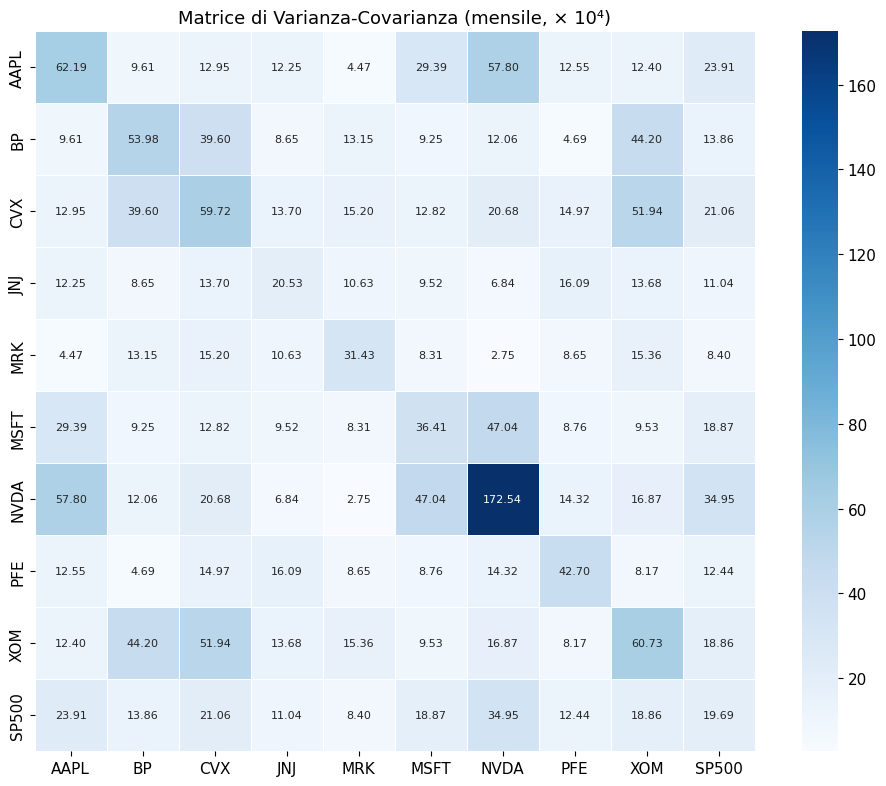

In [8]:
# Heatmap della matrice di covarianza
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cov_matrix * 10000,    # × 10000 per visualizzare in unità di (%)²
    annot=True, fmt='.2f', cmap='Blues',
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matrice di Varianza-Covarianza (mensile, × 10⁴)', fontsize=13)
fig.tight_layout()
plt.show()

---
## Blocco 5 – Matrice di correlazione

**ρᵢⱼ = Cov(rᵢ, rⱼ) / (σᵢ × σⱼ)** — valori in [−1, +1]

Interpretazione della heatmap:
- **Rosso scuro** → correlazione alta (+1): si muovono insieme
- **Bianco** → correlazione nulla (0): indipendenti
- **Blu scuro** → correlazione negativa (−1): si muovono in senso opposto

Una buona diversificazione si riconosce da blocchi off-diagonali chiari (bassa correlazione tra settori).

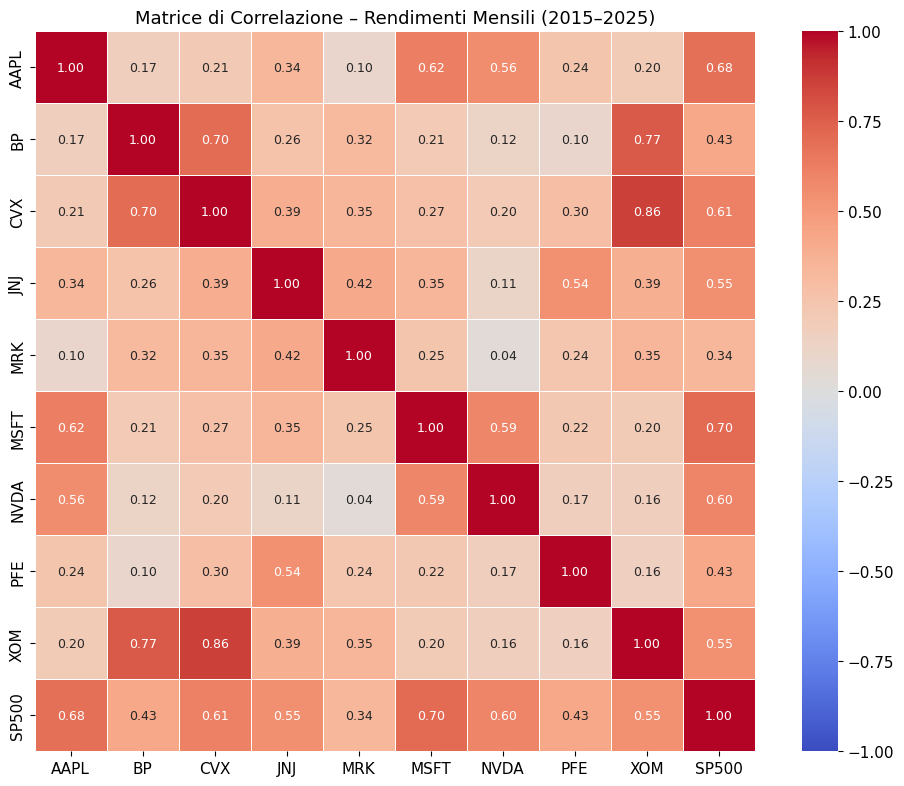

Heatmap salvata: correlation_heatmap.png


In [9]:
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Matrice di Correlazione – Rendimenti Mensili (2015–2025)', fontsize=13)
fig.tight_layout()
fig.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('Heatmap salvata: correlation_heatmap.png')

---
## Blocco 6 – Grafico rendimento atteso vs rischio (scatter)

Visualizzazione preliminare dei 10 asset nello spazio (σ, μ).
Questo grafico anticipa la frontiera efficiente che costruiremo nei prossimi punti.
I titoli in alto a sinistra sono i più efficienti (alto rendimento, basso rischio).

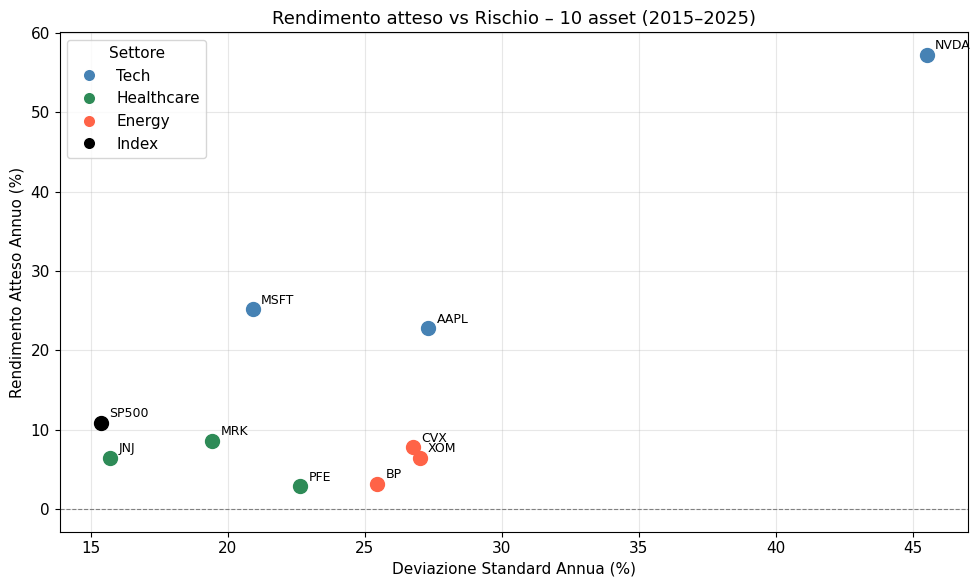

In [10]:
# Colori per settore
sector_colors = {}
palette = {'Tech': 'steelblue', 'Healthcare': 'seagreen', 'Energy': 'tomato', 'Index': 'black'}
for sector, tickers in TICKERS.items():
    for t in tickers:
        name = 'SP500' if t == '^GSPC' else t
        sector_colors[name] = palette[sector]

mu_ann    = mean_returns * ann * 100          # rendimento atteso annuo (%)
sigma_ann = std_returns * np.sqrt(ann) * 100  # std dev annua (%)

fig, ax = plt.subplots(figsize=(10, 6))
for ticker in returns.columns:
    ax.scatter(sigma_ann[ticker], mu_ann[ticker],
               color=sector_colors[ticker], s=100, zorder=3)
    ax.annotate(ticker, (sigma_ann[ticker], mu_ann[ticker]),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

# Legenda manuale per settore
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=s)
                   for s, c in palette.items()]
ax.legend(handles=legend_elements, title='Settore', loc='upper left')

ax.set_xlabel('Deviazione Standard Annua (%)')
ax.set_ylabel('Rendimento Atteso Annuo (%)')
ax.set_title('Rendimento atteso vs Rischio – 10 asset (2015–2025)', fontsize=13)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('risk_return_scatter.png', dpi=150)
plt.show()